In [6]:
# ===== IMPORTS =====
import pandas as pd
import numpy as np
import networkx as nx
import torch

In [7]:
import os
import sys

# Get absolute path of project root (one level up from notebooks)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add root to system path
sys.path.append(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\Diya\Desktop\fraud_ml


In [8]:
# import pandas as pd
# import networkx as nx
# df = pd.read_csv(r"C:\Users\Diya\Desktop\fraud_ml\data\train_transaction.csv")
# identity = pd.read_csv(r"C:\Users\Diya\Desktop\fraud_ml\data\train_identity.csv")
# df = df.merge(identity, on="TransactionID", how="left")

import pandas as pd
import os

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))

transactions_path = os.path.join(PROJECT_ROOT, "data", "train_transaction.csv")
identity_path = os.path.join(PROJECT_ROOT, "data", "train_identity.csv")

df = pd.read_csv(transactions_path)
identity = pd.read_csv(identity_path)


df = df.merge(identity, on="TransactionID", how="left")


In [9]:
df = df.sample(20000, random_state=42)


In [10]:
G = nx.Graph()

for _, row in df.iterrows():

    transaction_id = f"T_{row['TransactionID']}"
    account_id = f"A_{row['card1']}"
    device = f"D_{row['DeviceType']}"
    email = f"E_{row['P_emaildomain']}"

    # Add nodes
    G.add_node(transaction_id, type="transaction", fraud=row["isFraud"])
    G.add_node(account_id, type="account")
    G.add_node(device, type="device")
    G.add_node(email, type="email")

    # Add edges
    G.add_edge(account_id, transaction_id)
    G.add_edge(transaction_id, device)
    G.add_edge(transaction_id, email)

print("Total nodes:", G.number_of_nodes())
print("Total edges:", G.number_of_edges())


Total nodes: 23601
Total edges: 60000


In [11]:
fraud_nodes = [n for n, attr in G.nodes(data=True) 
               if attr.get("type") == "transaction" and attr.get("fraud") == 1]

print("Fraud transactions:", len(fraud_nodes))


Fraud transactions: 714


In [12]:
import torch
# Create mapping
node_to_idx = {node: idx for idx, node in enumerate(G.nodes())}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

In [13]:
edges = []
for source, target in G.edges():
    edges.append([node_to_idx[source], node_to_idx[target]])
    edges.append([node_to_idx[target], node_to_idx[source]])  # Undirected graph

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
print(edge_index.shape)

torch.Size([2, 120000])


In [14]:
selected_features = (
    ["TransactionAmt","card1","card2","card3","card5","addr1","addr2","dist1"] +
    [f"C{i}" for i in range(1,15)] +
    [f"D{i}" for i in range(1,11)] +
    [f"V{i}" for i in range(1,21)]
)
print(len(selected_features))

52


In [15]:
from sklearn.preprocessing import StandardScaler

df[selected_features] = df[selected_features].fillna(0)

scaler = StandardScaler()
df[selected_features] = scaler.fit_transform(df[selected_features])

In [16]:
feature_dim = len(selected_features)

x = torch.zeros((num_nodes, feature_dim))

print(len(selected_features))

NameError: name 'num_nodes' is not defined

NameError: name 'selected_features' is not defined

In [ ]:
num_nodes = G.number_of_nodes()
x = torch.randn((num_nodes, 16))  # 16-d initial feature

In [ ]:
txn_feature_dict = df.set_index("TransactionID")[selected_features].to_dict("index")

for node, attr in G.nodes(data=True):
    if attr.get("type") == "transaction":
        idx = node_to_idx[node]

        txn_id = int(node.split("_")[1])

        if txn_id in txn_feature_dict:
            x[idx] = torch.tensor(
                list(txn_feature_dict[txn_id].values()),
                dtype=torch.float
            )

In [ ]:
data.x = x

In [ ]:
y = torch.full((num_nodes,), -1, dtype=torch.long)
for node, attr in G.nodes(data=True):
    if attr.get("type") == "transaction":
        idx = node_to_idx[node]
        y[idx] = attr.get("fraud", 0)


In [ ]:
from torch_geometric.data import Data
data = Data(x=x, edge_index=edge_index, y=y)
print(data)

Data(x=[23601, 52], edge_index=[2, 120000], y=[23601])


In [ ]:
print((y != -1).sum())

tensor(20000)


In [ ]:
#REAL GNN TRAINING

In [ ]:
import torch
from sklearn.model_selection import train_test_split

# Get indices of transaction nodes
transaction_indices = (data.y != -1).nonzero(as_tuple=True)[0]

# Split
train_idx, test_idx = train_test_split(
    transaction_indices.numpy(),
    test_size=0.2,
    stratify=data.y[transaction_indices].numpy(),
    random_state=42
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.test_mask = test_mask


In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index, return_embeddings=False):
        x = self.conv1(x, edge_index)
        x = F.relu(x)

        embeddings = x  # 🔥 this is what we need

        x = self.conv2(x, edge_index)

        if return_embeddings:
            return embeddings

        return x


In [ ]:
model = GraphSAGE(in_channels=feature_dim, hidden_channels=64, out_channels=2)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()


In [ ]:
for epoch in range(100):
    
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 0.6034
Epoch 10, Loss: 0.1698
Epoch 20, Loss: 0.1484
Epoch 30, Loss: 0.1380
Epoch 40, Loss: 0.1314
Epoch 50, Loss: 0.1286
Epoch 60, Loss: 0.1264
Epoch 70, Loss: 0.1243
Epoch 80, Loss: 0.1222
Epoch 90, Loss: 0.1202


In [ ]:
from sklearn.metrics import roc_auc_score

model.eval()
out = model(data.x, data.edge_index)

probs = torch.softmax(out, dim=1)[:, 1]

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = probs[data.test_mask].detach().cpu().numpy()

print("GNN ROC-AUC:", roc_auc_score(y_true, y_pred))


GNN ROC-AUC: 0.7870532371439812


In [ ]:
import os
# Change working directory to project root
os.chdir("C:/Users/Diya/Desktop/fraud_ml")
print(os.getcwd())

C:\Users\Diya\Desktop\fraud_ml


In [ ]:
import pickle
with open("data/graph.pkl", "wb") as f:
    pickle.dump(G, f)
print("Graph saved successfully in data/graph.pkl")

Graph saved successfully in data/graph.pkl


In [ ]:
np.save("data/y.npy", y)
print("Labels saved to data/y.npy")

Labels saved to data/y.npy


In [ ]:
transaction_ids = df['TransactionID'].values  # if from DataFrame
np.save("data/transaction_ids.npy", transaction_ids)
print("Transaction IDs saved to data/transaction_ids.npy")

Transaction IDs saved to data/transaction_ids.npy


In [ ]:
txid_to_index = {tid: idx for idx, tid in enumerate(transaction_ids)}

import pickle
with open("data/txid_to_index.pkl", "wb") as f:
    pickle.dump(txid_to_index, f)

print("TransactionID → index mapping saved")

TransactionID → index mapping saved


In [ ]:
import networkx as nx
import pickle

# Suppose G exists
with open("data/graph.pkl", "wb") as f:
    pickle.dump(G, f)

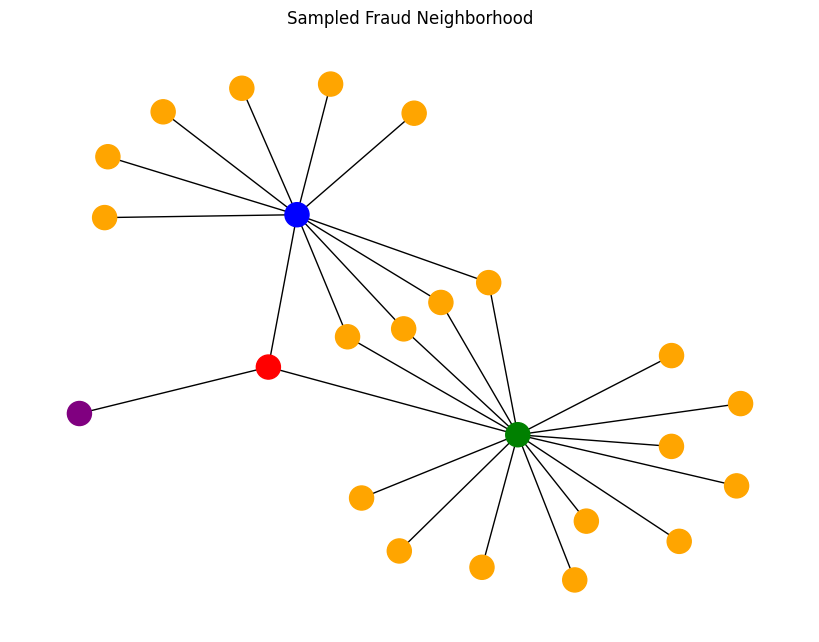

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import random

fraud_tx = random.choice(fraud_nodes)

# Direct neighbors only
neighbors = list(G.neighbors(fraud_tx))

sub_nodes = [fraud_tx]

for n in neighbors:
    sub_nodes.append(n)
    
    # If this is device or account, sample max 10 connected transactions
    if G.nodes[n]["type"] in ["device", "account"]:
        connected = [
            x for x in G.neighbors(n)
            if G.nodes[x]["type"] == "transaction"
        ]
        sub_nodes.extend(random.sample(connected, min(10, len(connected))))

sub_nodes = list(set(sub_nodes))
subG = G.subgraph(sub_nodes)

pos = nx.spring_layout(subG, seed=42)

colors = []
for node in subG.nodes():
    node_type = G.nodes[node].get("type")
    if node == fraud_tx:
        colors.append("red")
    elif node_type == "transaction":
        colors.append("orange")
    elif node_type == "account":
        colors.append("blue")
    elif node_type == "device":
        colors.append("green")
    elif node_type == "email":
        colors.append("purple")
    else:
        colors.append("gray")

plt.figure(figsize=(8, 6))
nx.draw(subG, pos,
        node_color=colors,
        node_size=300,
        with_labels=False)

plt.title("Sampled Fraud Neighborhood")
plt.show()


In [ ]:
import os
print(os.getcwd())


c:\Users\Diya\Desktop\fraud_ml\notebooks


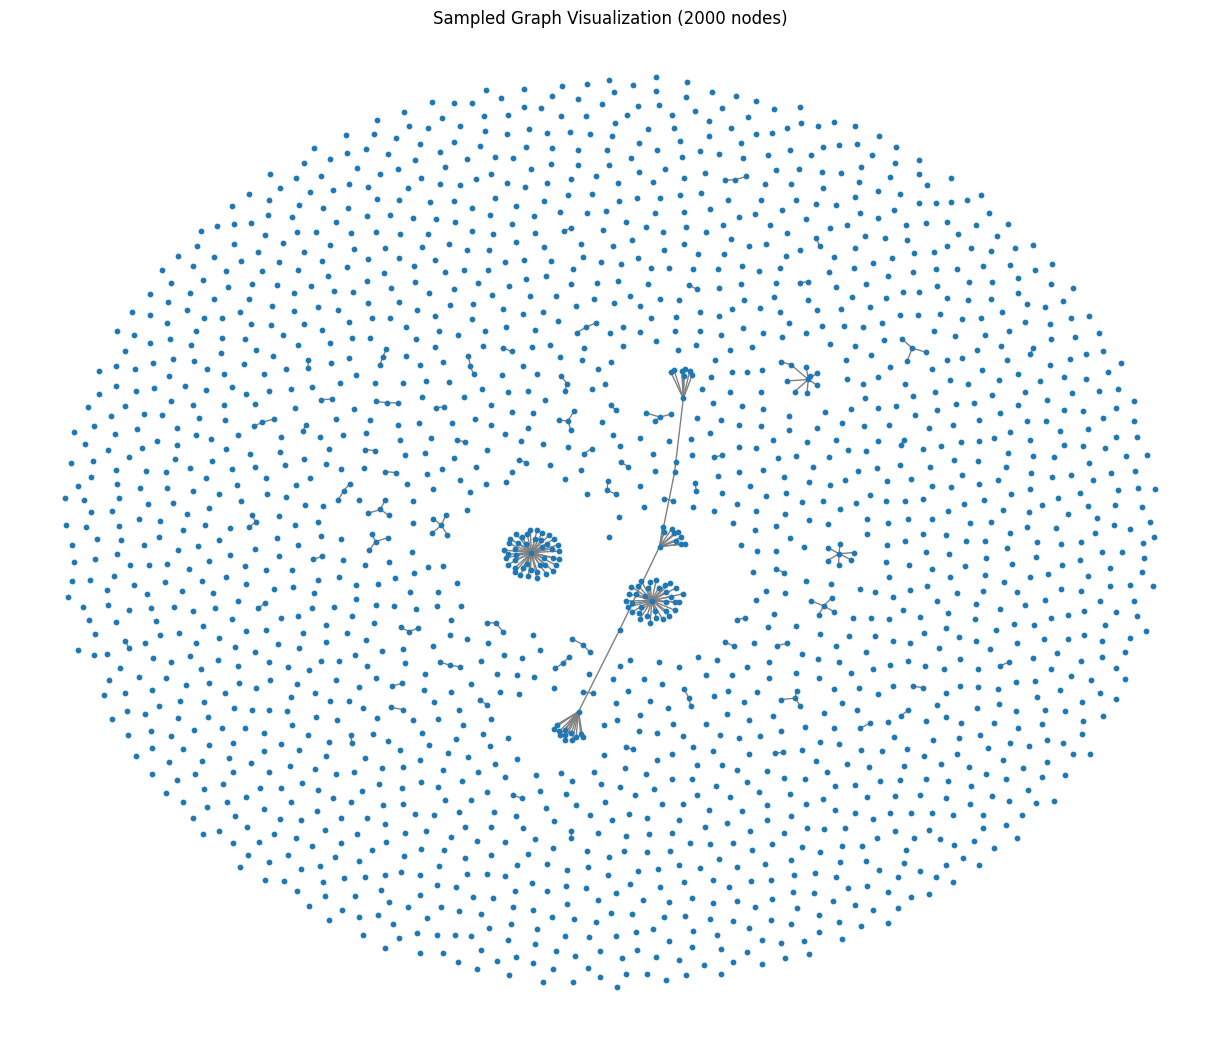

In [ ]:
import random
import matplotlib.pyplot as plt

# Sample 2000 nodes
sample_nodes = random.sample(list(G.nodes()), 2000)

subG = G.subgraph(sample_nodes)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(subG, k=0.15)

nx.draw(
    subG,
    pos,
    node_size=10,
    edge_color="gray",
    with_labels=False
)

plt.title("Sampled Graph Visualization (2000 nodes)")
plt.show()

In [ ]:
pip install pyvis

  Obtaining dependency information for pyvis from https://files.pythonhosted.org/packages/ab/4b/e37e4e5d5ee1179694917b445768bdbfb084f5a59ecd38089d3413d4c70f/pyvis-0.3.2-py3-none-any.whl.metadata
  Obtaining dependency information for jsonpickle>=1.4.1 from https://files.pythonhosted.org/packages/c1/73/04df8a6fa66d43a9fd45c30f283cc4afff17da671886e451d52af60bdc7e/jsonpickle-4.1.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   - -------------------------------------- 30.7/756.0 kB ? eta -:--:--
   - -------------------------------------- 30.7/756.0 kB ? eta -:--:--
   - -------------------------------------- 30.7/756.0 kB ? eta -:--:--
   --- ----------------------------------- 61.4/756.0 kB 297.7 kB/s eta 0:00:03
   --- ----------------------------------- 61.4/756.0 kB 297.7 kB/s eta 0:00:03
   -


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from pyvis.network import Network

net = Network(notebook=True)

# Step 1: Sample nodes
sample_nodes = set(list(G.nodes())[:2000])

# Step 2: Add nodes
for node in sample_nodes:
    node_type = G.nodes[node].get("type")

    if node_type == "transaction":
        color = "orange"
    elif node_type == "account":
        color = "blue"
    elif node_type == "device":
        color = "green"
    elif node_type == "email":
        color = "purple"
    else:
        color = "gray"

    net.add_node(node, color=color)

# Step 3: Add only valid edges
for u, v in G.edges():
    if u in sample_nodes and v in sample_nodes:
        net.add_edge(u, v)

# Step 4: Show
net.show("graph.html")

graph.html


In [17]:
# STEP 1 — MODIFY MODEL
def forward(self, x, edge_index, return_embeddings=False):
    x = self.conv1(x, edge_index)
    x = F.relu(x)

    embeddings = x

    x = self.conv2(x, edge_index)

    if return_embeddings:
        return embeddings

    return x

In [19]:
# STEP 2 — EXTRACT EMBEDDINGS
model.eval()
embeddings = model(data.x, data.edge_index, return_embeddings=True)

NameError: name 'model' is not defined

In [ ]:
STEP 3 — MAP TRANSACTIONS
txn_id_to_idx = {}

for node, idx in node_to_idx.items():
    if node.startswith("T_"):
        txn_id = int(node.split("_")[1])
        txn_id_to_idx[txn_id] = idx

In [ ]:
STEP 4 — BUILD EMBEDDING DATASET
import numpy as np

embedding_list = []
label_list = []

for txn_id in df["TransactionID"]:
    if txn_id in txn_id_to_idx:
        idx = txn_id_to_idx[txn_id]

        embedding_list.append(embeddings[idx].detach().numpy())
        label_list.append(
            df[df["TransactionID"] == txn_id]["isFraud"].values[0]
        )

X_gnn = np.array(embedding_list)
y = np.array(label_list)

In [ ]:
STEP 5 — GET TABULAR FEATURES
X_tab = df[selected_features].values

In [ ]:
STEP 6 — COMBINE
X_final = np.concatenate([X_gnn, X_tab], axis=1)

In [ ]:
STEP 7 — TRAIN FINAL MODEL
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, stratify=y
)

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
)

model_xgb.fit(X_train, y_train)

preds = model_xgb.predict_proba(X_test)[:,1]

print("Hybrid ROC-AUC:", roc_auc_score(y_test, preds))

Hybrid ROC-AUC: 0.8686676300106426


In [ ]:
import numpy as np

np.save("../data/X_final.npy", X_final)

In [ ]:
np.save("../data/X_tab.npy", X_tab)
np.save("../data/X_gnn.npy", X_gnn)

In [ ]:
tabular_feature_names = [
    "TransactionAmt", "card1", "card2", "card3", "card5",
    "addr1", "addr2", "dist1",

    # C features
    "C1","C2","C3","C4","C5","C6","C7","C8","C9","C10","C11","C12","C13","C14",

    # D features
    "D1","D2","D3","D4","D5","D6","D7","D8","D9","D10",

    # V features
    "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10",
    "V11","V12","V13","V14","V15","V16","V17","V18","V19","V20"
]

In [ ]:
import joblib

joblib.dump(tabular_feature_names, "../data/tabular_feature_names.pkl")

['../data/tabular_feature_names.pkl']

In [ ]:
print(len(tabular_feature_names))
print(X_tab.shape)

52
(20000, 52)


In [ ]:
print(X_gnn.shape)
print(X_gnn[:5])  # first 5 embeddings

(20000, 64)
[[0.00000000e+00 0.00000000e+00 1.08239427e-01 0.00000000e+00
  8.42826962e-01 6.52060270e-01 0.00000000e+00 4.60031033e-01
  0.00000000e+00 5.02082109e-01 0.00000000e+00 0.00000000e+00
  2.09054947e+00 0.00000000e+00 0.00000000e+00 1.33748686e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.85386807e-01
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  7.36550331e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.88049406e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  4.70411837e-01 1.99767619e-01 0.00000000e+00 1.01653957e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  3.87111127e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  1.09160566e+00 5.63972294e-01 0.00000000e+00 0.00000000e

In [ ]:
fraud_emb = X_gnn[y == 1]
normal_emb = X_gnn[y == 0]

print("Fraud mean:", fraud_emb.mean(axis=0)[:5])
print("Normal mean:", normal_emb.mean(axis=0)[:5])

Fraud mean: [0.19729131 0.30221137 0.20143083 0.24956882 0.3265796 ]
Normal mean: [0.12974763 0.57366437 0.23238114 0.44501132 0.74361473]


In [ ]:
import numpy as np

print("Mean:", np.mean(X_gnn))
print("Std:", np.std(X_gnn))

Mean: 0.42561963
Std: 0.83859724


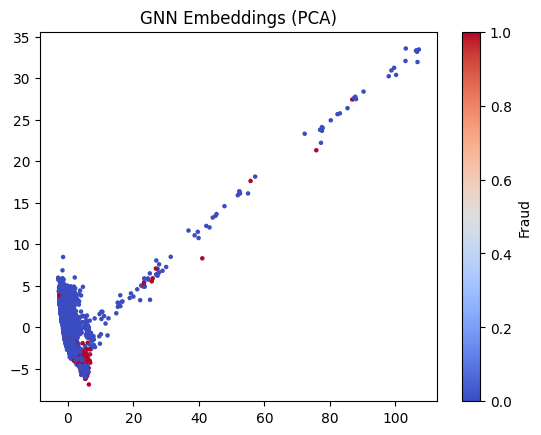

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_gnn)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', s=5)
plt.title("GNN Embeddings (PCA)")
plt.colorbar(label="Fraud")
plt.show()

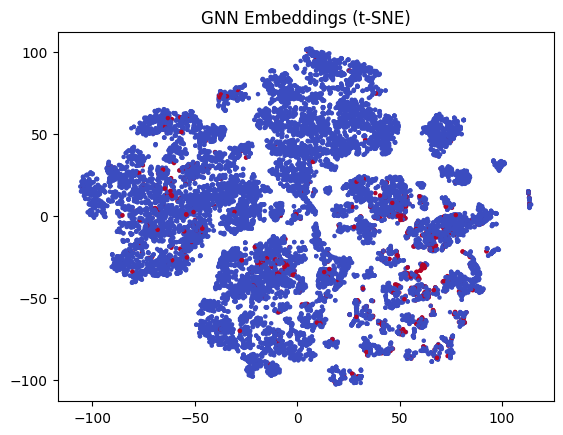

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X_gnn)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='coolwarm', s=5)
plt.title("GNN Embeddings (t-SNE)")
plt.show()

In [ ]:
import pandas as pd
df_emb = pd.DataFrame(X_gnn, columns=[f"emb_{i}" for i in range(X_gnn.shape[1])])
corr = df_emb.corrwith(pd.Series(y))
print(corr.sort_values(ascending=False).head())

emb_56    0.170177
emb_22    0.169473
emb_24    0.153203
emb_27    0.152870
emb_62    0.135522
dtype: float64


In [ ]:
!pip install matplotlib seaborn

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/30/4e/c10f171b6e2f44d9e3a2b96efa38b1677439d79c99357600a62cc1e9594e/matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/19/e8/6026ed58a64563186a9ee3f29f41261fd1828f527dd93d33b60feca63352/contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cac


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
y_pred = model.predict(X_test)

NameError: name 'model' is not defined